## Global Population and Fertility Outlook (2025).
**Obejctive**
- To analyze how population health indicators contributes to growth <br> across continents, using 2025 demographic data on <br> on birth, death, and fertility rates.
 
**Methods**

- Aggregation by continent
- Correlation analysis
- Visualization with Python(Matplotlib/searborn)
- Insight interpreted in global health context<br>
 
**Data Description:** <br>
- Real world dataset obtained from: *workwithdata.com* <br> 
- Last updated 176 days ago
 
**Features analyzed**
- Continent
- Country (per 1,000 people)
- Birth Rate (per 1,000 people)
- Death Rate (per 1,000 people)
- Fertility Rate (children per women)
- Population

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
file = r"C:\Users\USER\Documents\datasets\birth-dirth, fertility rate and population of countries\Dataset of key metrics of countries.csv"
if os.path.exists:
    print("File found!")
else:
    print("File not found!")
df = pd.read_csv(file)

df.head(5)

File found!


,country,continent,birth rate,death rate,fertility rate,population
0,India,Asia,16.267,9.074,2.011,1438069596
1,China,Asia,6.770,7.370,1.175,1410710000
2,United States,Americas,11.000,9.800,1.665,334914895
3,Indonesia,Asia,16.196,9.590,2.153,281190067
4,Pakistan,Asia,27.233,7.021,3.410,247504495


In [3]:
# adding underscores to spaced column names and capitalizing first letter for better readability
df.columns = [cols.replace(' ', '_').title() for cols in df.columns]

## Population Structure by continent
*how much of the world's population lives in each continent*

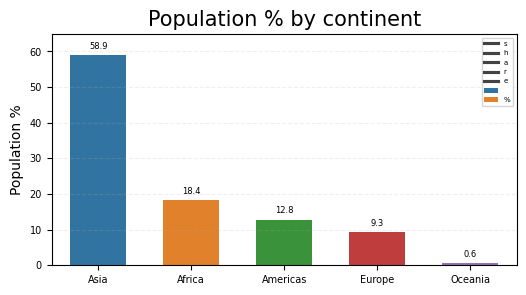

In [4]:
# Grouping by continent to  calculate contribution to global population percentage
continent_pop = df.groupby('Continent')['Population'].sum().reset_index()

# Engineering new column for population percentage
continent_pop['Share%'] = ((continent_pop['Population']/continent_pop['Population'].sum())*100)
continent_pop = continent_pop.sort_values(by='Share%', ascending=False)


# plot population percentage by continent
plt.figure(figsize=(6, 3))
ax = sns.barplot(data=continent_pop,
            x='Continent',
            y='Share%',
            hue='Continent',
            width=0.6
            )
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f',
                padding=3,
                fontsize=6)
plt.title('Population % by continent', 
          fontweight='normal',
          fontsize=15)
ax.margins(y=0.1)

plt.legend('share %',
           fontsize=5,
           title_fontsize=5)
ax.tick_params(axis='x',
               labelsize=7)
ax.tick_params(axis='y',
               labelsize=7)
plt.ylabel('Population %')
plt.xlabel(None)
plt.grid(axis='y', 
         linestyle='--',
         alpha=0.2)
plt.show()

continent_pop.to_csv('population_by_continent.csv', index=False)

**Insight**
- Asia accounts for 58.9% of the world's populatiion, followed by Africa at 18.4,<br> reflecting global population concentration.
- While Oceania ranks the lowest contributors to world population foollowed by Europe 

## Average Birth and Death Rates by Continent

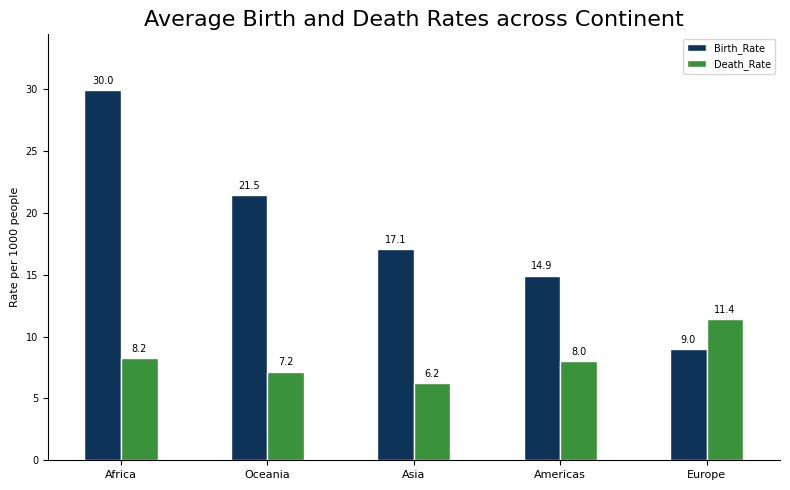

In [5]:
# Grouping continents by average birth and death rate
avg_b_d_rate = df.groupby('Continent')[['Birth_Rate', 'Death_Rate']].mean().reset_index().sort_values(by='Birth_Rate', ascending=False)

# Melting grouped dataframe into long format plotting
avg_b_d_rate_melted = avg_b_d_rate .melt(
     id_vars='Continent',
    value_vars=['Birth_Rate', 'Death_Rate'],
    var_name='Rate_Type',
    value_name='Rate'
)
avg_b_d_rate_melted


# plotting average birth and death rates by continent
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=avg_b_d_rate_melted,
             x='Continent',
             y='Rate',
             hue='Rate_Type',
             palette=['#003366', '#2ca02c'],
             width=0.5,
                 edgecolor='white',
                 linewidth=1,
                gap=0,
                )
for container in ax.containers:
    ax.bar_label(container,
                 fmt='%.1f',
                 padding=3,
                 fontsize=7
                )
    
ymax= avg_b_d_rate_melted['Rate'].max()
ax.set_ylim(0, ymax*1.15)

ax.tick_params(
    axis='x',
              labelsize=8)
ax.tick_params(axis='y',
              labelsize=7
              )
plt.title(
    'Average Birth and Death Rates across Continent', 
          fontweight='normal',
          fontsize=16
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(fontsize=7,
           title_fontsize=8)
plt.ylabel('Rate per 1000 people',
          fontsize=8)
plt.xlabel(None)
plt.grid(False)
plt.tight_layout()
plt.savefig('Avg_birth.png', dpi=300)
plt.show()


**Summary**
- Africa and Oceania maintain the highest birth rates by 30.0 and 21.4 respectively, <br>while Europe shows the highest death rate reflecting older populations and lower fertility. 

## Fertility Rate vs Birth Rate relationship

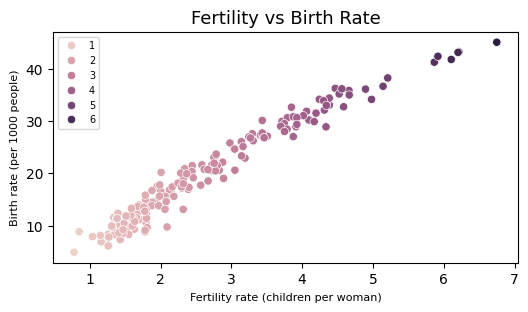

correlation:  0.98


In [6]:
# using the corrrelation method to determine relationship
corr = (df['Fertility_Rate'].corr(df['Birth_Rate'])).round(2)

# plotting a scatter plot comparing fertility rate and birth rate
plt.figure(figsize=(6, 3))
sns.scatterplot(df,
                x='Fertility_Rate', 
                y='Birth_Rate',
                hue='Fertility_Rate',
                )
plt.title('Fertility vs Birth Rate',
         fontweight='normal',
          fontsize=13)
plt.xlabel('Fertility rate (children per woman)',
          fontsize=8)

plt.ylabel('Birth rate (per 1000 people)',
          fontsize=8)
plt.legend(fontsize=7,
           title_fontsize=8)
# plt.grid(linestyle='--',
#          alpha=0.2)
plt.show()
print("correlation: ", corr)

**Summary**

- The scatterplot shows an almost perfect positive relationship between <br> fertility and birth rate. 
- Fewer fertility rate < 3 children per woman <br> shows 5 to 10 birth rate per 1000 people and this is most likely observed <br> in already developed continent like Europe ***reference Average<br> birth and Death rates plot***, compared to a developing continent like Africa where <br> fertility rate > 4 children per woman equals 35 to 40 birth rate per 1000<br> observation,(hence correlation = 0.98).

## Birth-to-Death Ratio by Continent

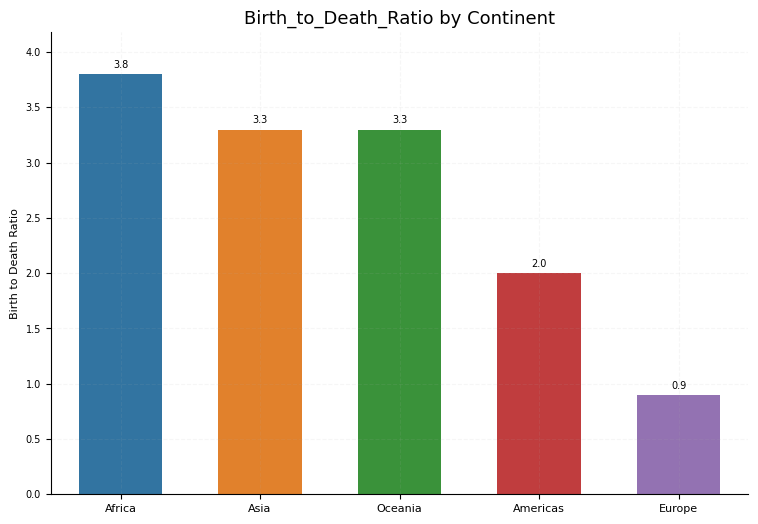

  Continent  Birth_to_Death_Ratio
0    Africa                   3.8
2      Asia                   3.3
4   Oceania                   3.3
1  Americas                   2.0
3    Europe                   0.9


In [7]:
# Create new column to compare births and deaths directly
df['Birth_to_Death_Ratio'] = (df['Birth_Rate']/df['Death_Rate'])

# Grouping birth to date ratio by continent
continent_ratio = df.groupby('Continent')['Birth_to_Death_Ratio'].mean().reset_index().sort_values(by='Birth_to_Death_Ratio', ascending=False).round(1)

plt.figure(figsize=(9, 6))
ax =sns.barplot(continent_ratio,
           x='Continent',
           y='Birth_to_Death_Ratio',
           hue='Continent',
           width=0.6,)
for container in ax.containers:
    ax.bar_label(container,
                 fmt='%.1f',
                 padding=3,
                 fontsize=7
                )
plt.title('Birth_to_Death_Ratio by Continent',
         fontweight='normal',
          fontsize=13)
ax.margins(y=0.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=7)
plt.ylabel('Birth to Death Ratio', fontsize=8)
plt.xlabel(None)
plt.grid(linestyle='--', alpha=0.1)
plt.show()

print(continent_ratio)

**Summary**
- Africa takes the lead in Birth to Death ratio by which signifies rapid <br> natural population growth, with Europe as the lowest, suggesting a decline <br> and stagnation in population growth.

## Fertility and Development Insight

In [8]:
# Grouping fertility rate by continent
df.groupby('Continent')['Fertility_Rate'].mean().sort_values(ascending=False).round(1)

Continent
Africa      4.0
Oceania     2.8
Asia        2.3
Americas    1.9
Europe      1.5
Name: Fertility_Rate, dtype: float64

**Insight**

- High fertility in Africa (~ 4 children per woman) contrasts sharply with <br>Europe's 1.5, showing a nearly 3:1 potential for future population <br>growth, assuming other factors remain the same.